# Convolutional Neural Networks for Image Classification
## Using a CNN for Feature Extraction

This notebook explores two ways to exploit a **pre-trained AlexNet** (trained on ImageNet) for CIFAR-10 classification:

1. Freeze all layers, replace only the final classifier layer, and train just that layer.
2. Remove the final layer entirely, extract deep feature vectors, and train a **Linear SVM** on them.

### 1. Imports & Device Configuration

In [1]:
# Basic imports
import time, os, sys, numpy as np
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torchsummary import summary
import time, os, sys, numpy as np
# Test if GPU is avaliable, if not, use cpu instead
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n = torch.cuda.device_count()
devices_ids = list(range(n))
print('Using device:', device)

Using device: cpu


### 2. Data Loading & Helper Functions

Reusing the same `load_data_cifar10`, `evaluate_accuracy`, and `train_validate` functions from cifar10-dataloader.ipynb.

In [2]:
def load_data_cifar10(batch_size, resize=None, root=os.path.join(
    '~', '.pytorch', 'datasets', 'fashion-mnist')):
    """Download the Cifar10 dataset and then load into memory."""
    root = os.path.expanduser(root)
    transformer = []
    if resize:
        transformer += [torchvision.transforms.Resize(resize)]
    transformer += [torchvision.transforms.ToTensor()]
    transformer = torchvision.transforms.Compose(transformer)
    mnist_train = torchvision.datasets.CIFAR10(
        root=root, train=True, download=True, transform=transformer)
    mnist_test = torchvision.datasets.CIFAR10(
        root=root, train=False, download=True, transform=transformer)
    num_workers = 0 if sys.platform.startswith('win32') else 4
    train_iter = torch.utils.data.DataLoader(
        mnist_train, batch_size, shuffle=True, num_workers=num_workers)
    test_iter = torch.utils.data.DataLoader(
        mnist_test, batch_size, shuffle=False, num_workers=num_workers)
    return train_iter, test_iter


def evaluate_accuracy(data_iter, net, loss):
    """Evaluate accuracy of a model on the given data set."""
    acc_sum, n, l = torch.Tensor([0]), 0, 0
    net.eval()
    with torch.no_grad():
        for X, y in data_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l += loss(y_hat, y).sum()
            acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]
    return acc_sum.item() / n, l.item() / len(data_iter)


def train_validate(net, train_iter, test_iter, batch_size, trainer, loss, num_epochs):
    print('training on', device)
    history = []
    for epoch in range(num_epochs):
        net.train()
        train_l_sum, train_acc_sum, n, start = 0.0, 0.0, 0, time.time()
        for X, y in train_iter:
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            trainer.zero_grad()
            l = loss(y_hat, y).sum()
            l.backward()
            trainer.step()
            train_l_sum += l.item()
            train_acc_sum += (y_hat.argmax(axis=1) == y).sum().item()
            n += y.size()[0]
        test_acc, test_loss = evaluate_accuracy(test_iter, net, loss)
        train_loss = train_l_sum / len(train_iter)
        train_acc = train_acc_sum / n
        history.append({
            'epoch': epoch + 1,
            'train_loss': train_loss,
            'train_acc': train_acc,
            'test_loss': test_loss,
            'test_acc': test_acc,
        })
        print('epoch %d, train loss %.4f, train acc %.3f, test loss %.4f, '
              'test acc %.3f, time %.1f sec'
              % (epoch + 1, train_loss, train_acc, test_loss,
                 test_acc, time.time() - start))
    return history

### 3. Load Pre-trained AlexNet & Freeze All Parameters

We load AlexNet pre-trained on ImageNet, freeze all weights (`requires_grad = False`), then replace the last layer for 10-class output and inspect the architecture.

In [3]:
import warnings
warnings.filterwarnings('ignore')  # suppress pretrained= deprecation warning

# AlexNet-based network pre-trained on ImageNet
net = torchvision.models.alexnet(pretrained=True)

# Sending model to device
net.to(device)

# Freeze all learnable parameters (learning rate = 0 for all layers)
for param in net.parameters():
    param.requires_grad = False

# Summary: all parameters are non-trainable at this point
print("--- Summary before replacing last layer (0 trainable params) ---")
print(summary(net, (3, 227, 227)))

# Get the input feature size of the last FC layer
num_ftrs = net.classifier[6].in_features

# Replace the last layer: 1000 ImageNet classes -> 10 CIFAR-10 classes
# Note: newly created layers have requires_grad=True by default
net.classifier[6] = nn.Linear(num_ftrs, 10)

# Send updated model to device
net.to(device)

# Print architecture to confirm last layer output is 10
print("\n--- Network architecture (last layer now outputs 10 classes) ---")
print(net)

# Summary: only the new last layer is trainable (~40,970 params)
print("\n--- Summary after replacing last layer (only fc8 is trainable) ---")
print(summary(net, (3, 227, 227)))

--- Summary before replacing last layer (0 trainable params) ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]          23,296
              ReLU-2           [-1, 64, 56, 56]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 13, 13]               0
        MaxPool2d-13            [-1, 2

### 4. Train Only the Last Layer

Only the newly replaced final linear layer has `requires_grad = True`. All convolutional and earlier FC layers act as a frozen feature encoder.

In [4]:
# Collect only the trainable parameters (the new last layer)
print("Params to learn:")
params_to_update = []
for name, param in net.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t", name)

num_epochs, lr, batch_size, wd_lambda = 10, 0.001, 100, 0.0001

loss = nn.CrossEntropyLoss()

# Loading data: cifar10
train_iter, test_iter = load_data_cifar10(batch_size, resize=227)

# Optimizer receives ONLY the trainable last-layer parameters
trainer = optim.Adam(params_to_update, lr=lr, weight_decay=wd_lambda)

# Training and validation
history = train_validate(net, train_iter, test_iter, batch_size, trainer, loss, num_epochs)

Params to learn:
	 classifier.6.weight
	 classifier.6.bias
Files already downloaded and verified
Files already downloaded and verified
training on cpu
epoch 1, train loss 1.2114, train acc 0.573, test loss 0.9741, test acc 0.666, time 327.9 sec
epoch 2, train loss 1.0967, train acc 0.612, test loss 0.9268, test acc 0.671, time 325.9 sec
epoch 3, train loss 1.0730, train acc 0.620, test loss 0.9214, test acc 0.674, time 337.5 sec
epoch 4, train loss 1.0600, train acc 0.624, test loss 0.9109, test acc 0.673, time 333.9 sec
epoch 5, train loss 1.0566, train acc 0.628, test loss 0.8728, test acc 0.694, time 328.7 sec
epoch 6, train loss 1.0529, train acc 0.626, test loss 0.8750, test acc 0.694, time 329.6 sec
epoch 7, train loss 1.0446, train acc 0.630, test loss 0.8845, test acc 0.689, time 331.9 sec
epoch 8, train loss 1.0466, train acc 0.627, test loss 0.9040, test acc 0.675, time 330.4 sec
epoch 9, train loss 1.0388, train acc 0.632, test loss 0.8910, test acc 0.681, time 336.5 sec
epo

### 4.1 Training Curves – Last-Layer Only

Loss and accuracy over epochs when only the final FC layer is trained.

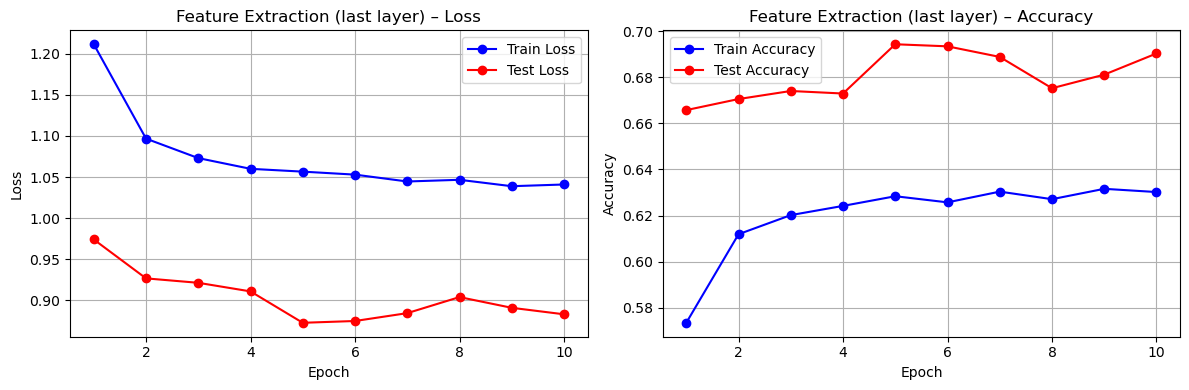

In [5]:
import matplotlib.pyplot as plt

epochs     = [h['epoch']      for h in history]
train_loss = [h['train_loss'] for h in history]
test_loss  = [h['test_loss']  for h in history]
train_acc  = [h['train_acc']  for h in history]
test_acc   = [h['test_acc']   for h in history]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, train_loss, 'b-o', label='Train Loss')
ax1.plot(epochs, test_loss,  'r-o', label='Test Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Feature Extraction (last layer) – Loss')
ax1.legend()
ax1.grid(True)

ax2.plot(epochs, train_acc, 'b-o', label='Train Accuracy')
ax2.plot(epochs, test_acc,  'r-o', label='Test Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Feature Extraction (last layer) – Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

### 5. AlexNet as a Feature Extractor + Linear SVM

The **last fully-connected layer is removed** entirely. AlexNet is used purely as a feature extractor, producing 4096-dimensional vectors per image. A **Linear SVM** is trained on these features.

In [6]:
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')

# Fresh pre-trained AlexNet
net = torchvision.models.alexnet(pretrained=True)

# Sending model to device
net.to(device)

# Loading dataset: cifar10
train_iter, test_iter = load_data_cifar10(batch_size, resize=227)

# Remove the last fully-connected layer to expose 4096-d feature vectors
new_classifier = nn.Sequential(*list(net.classifier.children())[:-1])
net.classifier = new_classifier

print("--- Network summary after removing last layer ---")
print(summary(net, (3, 227, 227)))

# Extract features for the training set
print("Extracting training features...")
first = True
with torch.no_grad():
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        features = net(X)
        if first is True:
            train_features = features.cpu().numpy()
            train_labels = y.cpu().numpy()
            first = False
        else:
            train_features = np.concatenate((train_features, features.cpu().numpy()))
            train_labels = np.concatenate((train_labels, y.cpu().numpy()))

# Extract features for the test set
print("Extracting test features...")
first = True
with torch.no_grad():
    for X, y in test_iter:
        X, y = X.to(device), y.to(device)
        features = net(X)
        if first is True:
            test_features = features.cpu().numpy()
            test_labels = y.cpu().numpy()
            first = False
        else:
            test_features = np.concatenate((test_features, features.cpu().numpy()))
            test_labels = np.concatenate((test_labels, y.cpu().numpy()))

print("Train features shape:", train_features.shape,
      "| Test features shape:", test_features.shape)

# Reduce dimensionality with PCA before SVM (4096 -> 256)
# This makes LinearSVC tractable on CPU without significant accuracy loss
print("Applying PCA (4096 -> 256 dimensions)...")
pca = PCA(n_components=256, random_state=42)
train_features_pca = pca.fit_transform(train_features)
test_features_pca  = pca.transform(test_features)
print(f"Variance explained: {pca.explained_variance_ratio_.sum():.3f}")
print("Reduced shapes — Train:", train_features_pca.shape,
      "| Test:", test_features_pca.shape)

# Train a Linear SVM on the PCA-reduced features
print("Training LinearSVC...")
clf = LinearSVC(max_iter=2000, random_state=42)
clf.fit(train_features_pca, train_labels)

# Evaluate on the test set
pred = clf.predict(test_features_pca)
print("Test accuracy (Linear SVM + PCA):", accuracy_score(test_labels, pred))

Files already downloaded and verified
Files already downloaded and verified
--- Network summary after removing last layer ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 56, 56]          23,296
              ReLU-2           [-1, 64, 56, 56]               0
         MaxPool2d-3           [-1, 64, 27, 27]               0
            Conv2d-4          [-1, 192, 27, 27]         307,392
              ReLU-5          [-1, 192, 27, 27]               0
         MaxPool2d-6          [-1, 192, 13, 13]               0
            Conv2d-7          [-1, 384, 13, 13]         663,936
              ReLU-8          [-1, 384, 13, 13]               0
            Conv2d-9          [-1, 256, 13, 13]         884,992
             ReLU-10          [-1, 256, 13, 13]               0
           Conv2d-11          [-1, 256, 13, 13]         590,080
             ReLU-12          [-1, 256, 1

### 5.1 SVM Results – Confusion Matrix & Per-Class Accuracy

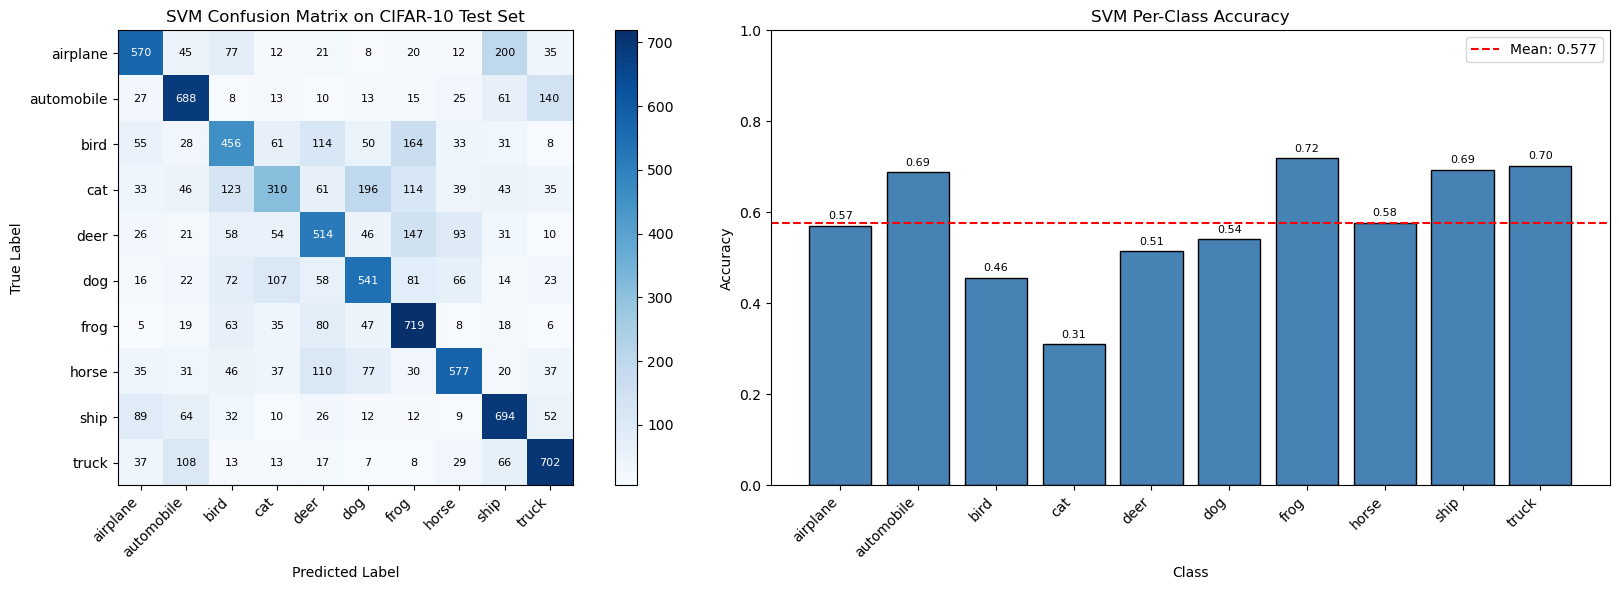

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cifar10_classes = ['airplane', 'automobile', 'bird', 'cat', 'deer',
                   'dog', 'frog', 'horse', 'ship', 'truck']

cm = confusion_matrix(test_labels, pred)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# --- Confusion matrix ---
im = ax1.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax1)
ax1.set_xticks(range(10))
ax1.set_yticks(range(10))
ax1.set_xticklabels(cifar10_classes, rotation=45, ha='right')
ax1.set_yticklabels(cifar10_classes)
ax1.set_xlabel('Predicted Label')
ax1.set_ylabel('True Label')
ax1.set_title('SVM Confusion Matrix on CIFAR-10 Test Set')
thresh = cm.max() / 2
for i in range(10):
    for j in range(10):
        ax1.text(j, i, str(cm[i, j]), ha='center', va='center',
                 color='white' if cm[i, j] > thresh else 'black', fontsize=8)

# --- Per-class accuracy bar chart ---
per_class_acc = cm.diagonal() / cm.sum(axis=1)
bars = ax2.bar(cifar10_classes, per_class_acc, color='steelblue', edgecolor='black')
ax2.set_xlabel('Class')
ax2.set_ylabel('Accuracy')
ax2.set_title('SVM Per-Class Accuracy')
ax2.set_ylim(0, 1)
ax2.set_xticklabels(cifar10_classes, rotation=45, ha='right')
ax2.axhline(y=per_class_acc.mean(), color='red', linestyle='--', label=f'Mean: {per_class_acc.mean():.3f}')
ax2.legend()
for bar, acc in zip(bars, per_class_acc):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
             f'{acc:.2f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()